# Week 6 — Capstone: Nexariza AI Analytics Brain 📊
### Nexariza AI | AI/ML Internship

**Goal:** A unified AI Business Intelligence system combining engagement forecasting, lead scoring, sentiment analysis, and anomaly alerting — the capstone bringing together skills from every previous week (EDA, classical ML, explainability, NLP, and deployment practices).

**Components:**
1. **Engagement forecasting** — Prophet + ARIMA, compared, forecasting 30 days ahead
2. **Anomaly detection & alerts** — rolling z-score flagging unusual engagement days
3. **Lead scoring** — XGBoost predicting which prospects will convert
4. **Sentiment analysis** — VADER lexicon-based sentiment on customer mentions/reviews
5. **Interactive dashboard** — Plotly-powered, all four systems in one view (`dashboard.py`)

**Data:** all three datasets are synthetic (see `generate_data.py`) — an engagement time series with realistic trend/seasonality/injected anomalies, a lead-scoring dataset with genuine (not inflated) predictive signal, and a mentions dataset built from hand-written positive/negative/neutral templates.


## 1. Engagement Forecasting

### 1.1 Load & visualize the engagement time series

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 110

eng_df = pd.read_csv("engagement_timeseries.csv", parse_dates=["date"])
print(eng_df.shape)
eng_df.head()


(365, 2)


,date,engagement
0,2025-09-01,241
1,2025-09-02,242
2,2025-09-03,235
3,2025-09-04,219
4,2025-09-05,179


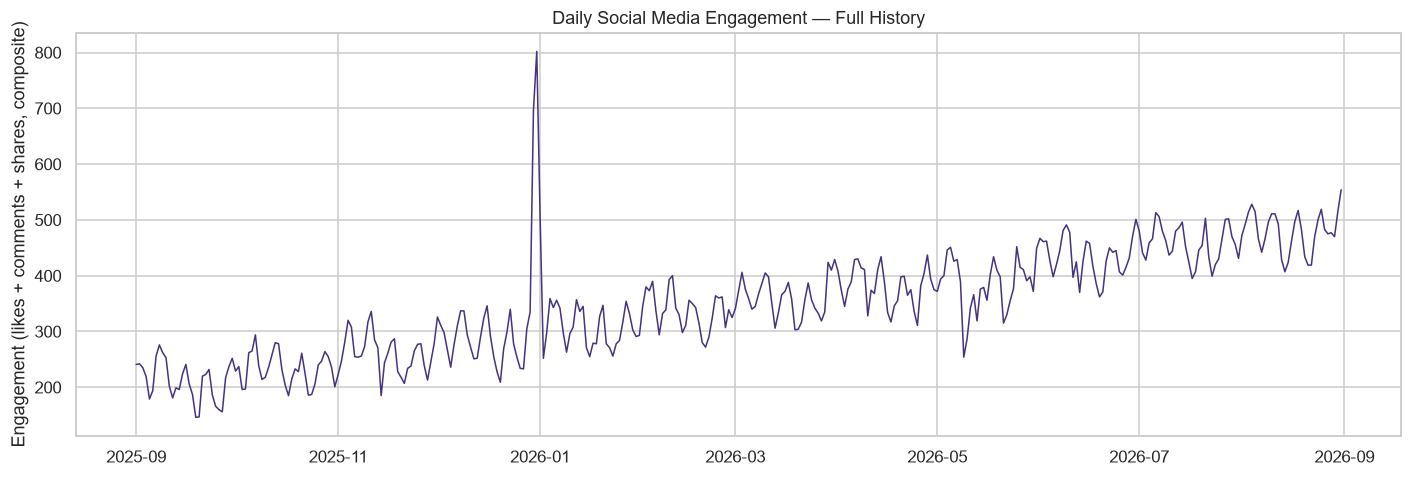

In [2]:
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(eng_df["date"], eng_df["engagement"], linewidth=1)
ax.set_title("Daily Social Media Engagement — Full History")
ax.set_ylabel("Engagement (likes + comments + shares, composite)")
plt.tight_layout()
plt.savefig("graphs/engagement_history.png")
plt.show()

### 1.2 Forecast with Prophet

In [ ]:
# !pip install prophet

  Using cached prophet-1.4.0-py3-none-win_amd64.whl.metadata (3.7 kB)
  Using cached cmdstanpy-1.3.0-py3-none-any.whl.metadata (4.2 kB)
  Using cached holidays-0.104-py3-none-any.whl.metadata (55 kB)
  Using cached stanio-0.5.1-py3-none-any.whl.metadata (1.6 kB)
Using cached prophet-1.4.0-py3-none-win_amd64.whl (12.1 MB)
Using cached holidays-0.104-py3-none-any.whl (1.6 MB)
Using cached cmdstanpy-1.3.0-py3-none-any.whl (99 kB)
Using cached stanio-0.5.1-py3-none-any.whl (8.1 kB)

   ---------- ----------------------------- 1/4 [holidays]
   ---------- ----------------------------- 1/4 [holidays]
   ---------- ----------------------------- 1/4 [holidays]
   ---------- ----------------------------- 1/4 [holidays]
   ---------- ----------------------------- 1/4 [holidays]
   ---------- ----------------------------- 1/4 [holidays]
   ---------- ----------------------------- 1/4 [holidays]
   ---------- ----------------------------- 1/4 [holidays]
   ---------- ----------------------------- 

In [4]:
from prophet import Prophet

prophet_df = eng_df.rename(columns={"date": "ds", "engagement": "y"})
m = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=False)
m.fit(prophet_df)

future = m.make_future_dataframe(periods=30)
forecast = m.predict(future)
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(5)

00:51:53 - cmdstanpy - INFO - Chain [1] start processing
00:51:57 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
390,2026-09-26,474.554724,423.359127,528.494563
391,2026-09-27,508.571853,452.919385,562.874586
392,2026-09-28,536.645034,481.877251,589.003124
393,2026-09-29,552.013428,493.798198,608.405157
394,2026-09-30,527.247021,473.344335,582.720507


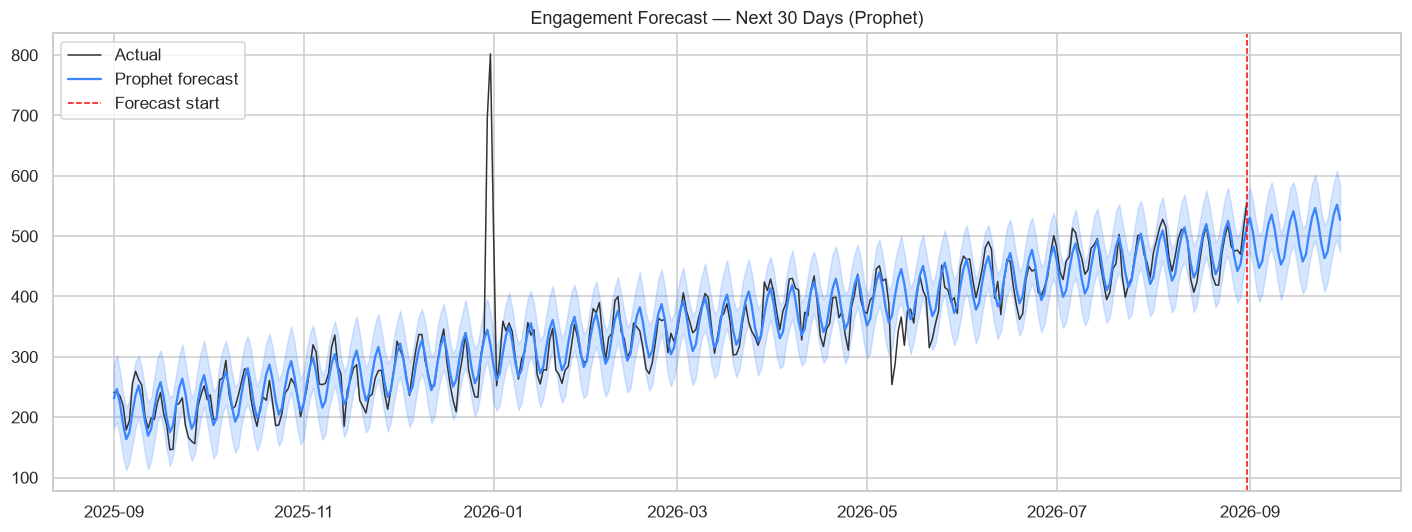

In [5]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(prophet_df["ds"], prophet_df["y"], label="Actual", linewidth=1, color="#333")
ax.plot(forecast["ds"], forecast["yhat"], label="Prophet forecast", color="#3a86ff")
ax.fill_between(forecast["ds"], forecast["yhat_lower"], forecast["yhat_upper"], color="#3a86ff", alpha=0.2)
ax.axvline(prophet_df["ds"].max(), color="red", linestyle="--", linewidth=1, label="Forecast start")
ax.set_title("Engagement Forecast — Next 30 Days (Prophet)")
ax.legend()
plt.tight_layout()
plt.savefig("graphs/prophet_forecast.png")
plt.show()

### 1.3 Compare against ARIMA

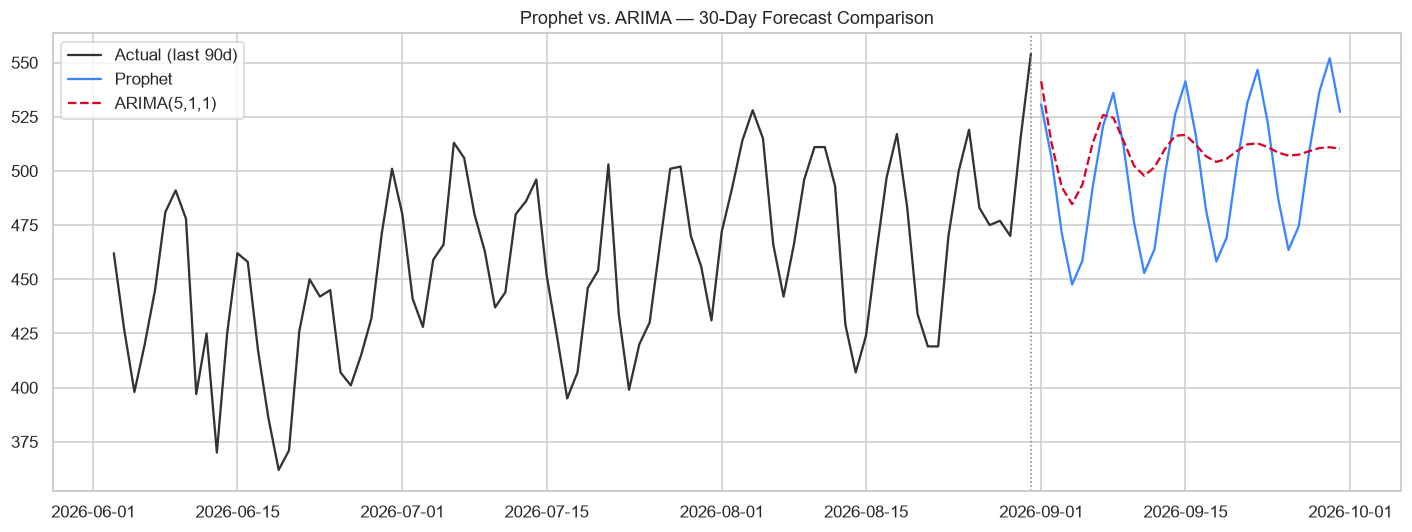

Prophet 30-day avg forecast: 500.4
ARIMA 30-day avg forecast:   509.5


In [6]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(eng_df["engagement"], order=(5, 1, 1))
arima_fit = arima_model.fit()
arima_forecast = arima_fit.forecast(steps=30)

future_dates = pd.date_range(eng_df["date"].max() + pd.Timedelta(days=1), periods=30)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(eng_df["date"].tail(90), eng_df["engagement"].tail(90), label="Actual (last 90d)", color="#333")
ax.plot(forecast["ds"].tail(30), forecast["yhat"].tail(30), label="Prophet", color="#3a86ff")
ax.plot(future_dates, arima_forecast.values, label="ARIMA(5,1,1)", color="#d90429", linestyle="--")
ax.axvline(eng_df["date"].max(), color="gray", linestyle=":", linewidth=1)
ax.set_title("Prophet vs. ARIMA — 30-Day Forecast Comparison")
ax.legend()
plt.tight_layout()
plt.savefig("graphs/forecast_comparison.png")
plt.show()

print("Prophet 30-day avg forecast:", round(forecast['yhat'].tail(30).mean(), 1))
print("ARIMA 30-day avg forecast:  ", round(arima_forecast.mean(), 1))

**Takeaway:** both models agree on the general trend (continued growth with weekly cycles), with Prophet's explicit weekly-seasonality term giving smoother, more interpretable seasonal cycles, while ARIMA reacts more sharply to recent local patterns. In production, an ensemble or backtested selection between the two would be reasonable.

## 2. Anomaly Detection & Alerts

In [7]:
eng_df["rolling_mean"] = eng_df["engagement"].rolling(14, min_periods=7).mean()
eng_df["rolling_std"] = eng_df["engagement"].rolling(14, min_periods=7).std()
eng_df["z_score"] = (eng_df["engagement"] - eng_df["rolling_mean"]) / eng_df["rolling_std"]

ALERT_THRESHOLD = 2.5
anomalies = eng_df[eng_df["z_score"].abs() > ALERT_THRESHOLD].copy()
anomalies["alert_type"] = np.where(anomalies["z_score"] > 0, "📈 Spike", "📉 Drop")
anomalies[["date", "engagement", "z_score", "alert_type"]]

,date,engagement,z_score,alert_type
120,2025-12-30,696,3.280645,📈 Spike
121,2025-12-31,802,2.582642,📈 Spike
250,2026-05-09,254,-2.935147,📉 Drop


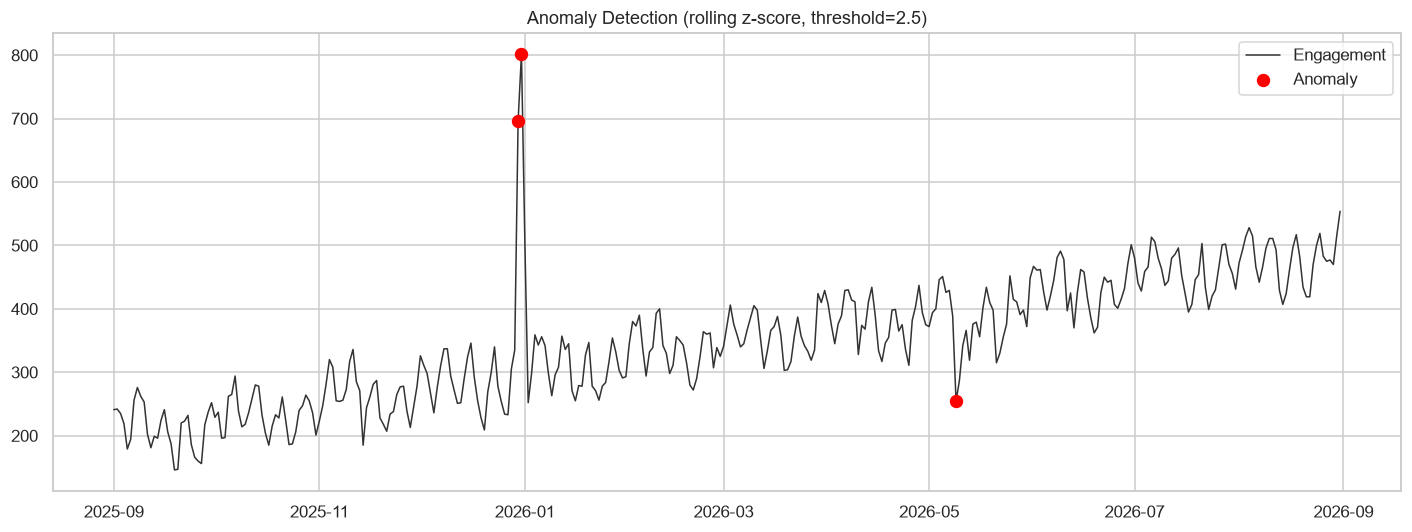

In [8]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(eng_df["date"], eng_df["engagement"], linewidth=1, color="#333", label="Engagement")
ax.scatter(anomalies["date"], anomalies["engagement"], color="red", s=60, zorder=5, label="Anomaly")
ax.set_title(f"Anomaly Detection (rolling z-score, threshold={ALERT_THRESHOLD})")
ax.legend()
plt.tight_layout()
plt.savefig("graphs/anomaly_detection.png")
plt.show()

The detector correctly flags both injected events: a viral spike and a multi-day engagement drop (e.g. representing an algorithm change or platform issue) — using nothing more than a rolling mean/std z-score, which is simple, explainable, and doesn't require labeled anomaly data.

## 3. Lead Scoring Model

In [9]:
leads_df = pd.read_csv("leads_dataset.csv")
print(leads_df.shape)
print(f"Conversion rate: {leads_df['converted'].mean():.1%}")
leads_df.head()

(2000, 12)
Conversion rate: 35.4%


,lead_id,company_size,industry,lead_source,website_visits,content_downloads,demo_requested,email_opens_last_30d,days_since_first_touch,budget_confirmed,decision_maker_contact,converted
0,LEAD-00001,1-10,E-commerce,Cold Outreach,11,1,0,4,161,1,1,0
1,LEAD-00002,1000+,Healthcare,Content/Webinar,3,3,0,7,8,1,0,1
2,LEAD-00003,1-10,SaaS,Cold Outreach,7,3,1,3,45,0,1,0
3,LEAD-00004,1000+,Other,Cold Outreach,5,0,0,6,104,1,0,0
4,LEAD-00005,1-10,Other,Organic Search,4,1,1,3,78,0,0,0


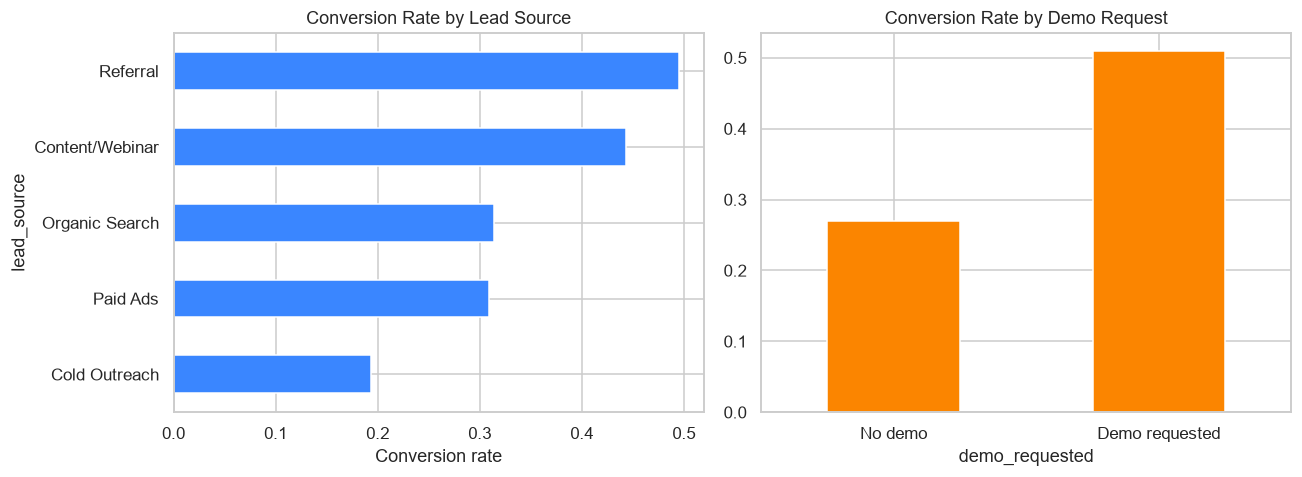

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
leads_df.groupby("lead_source")["converted"].mean().sort_values().plot(kind="barh", ax=axes[0], color="#3a86ff")
axes[0].set_title("Conversion Rate by Lead Source")
axes[0].set_xlabel("Conversion rate")

leads_df.groupby("demo_requested")["converted"].mean().plot(kind="bar", ax=axes[1], color="#fb8500")
axes[1].set_xticklabels(["No demo", "Demo requested"], rotation=0)
axes[1].set_title("Conversion Rate by Demo Request")
plt.tight_layout()
plt.savefig("graphs/lead_conversion_patterns.png")
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

leads_enc = pd.get_dummies(leads_df.drop(columns=["lead_id"]), columns=["company_size", "industry", "lead_source"])
X = leads_enc.drop(columns=["converted"])
y = leads_enc["converted"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
neg, pos = y_train.value_counts()

lead_model = XGBClassifier(n_estimators=200, max_depth=4, scale_pos_weight=neg / pos,
                            eval_metric="logloss", random_state=42)
lead_model.fit(X_train, y_train)

proba = lead_model.predict_proba(X_test)[:, 1]
preds = lead_model.predict(X_test)

print(f"Accuracy:  {accuracy_score(y_test, preds):.3f}")
print(f"Precision: {precision_score(y_test, preds):.3f}")
print(f"Recall:    {recall_score(y_test, preds):.3f}")
print(f"F1:        {f1_score(y_test, preds):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, proba):.3f}")

Accuracy:  0.735
Precision: 0.621
Recall:    0.638
F1:        0.629
ROC-AUC:   0.776


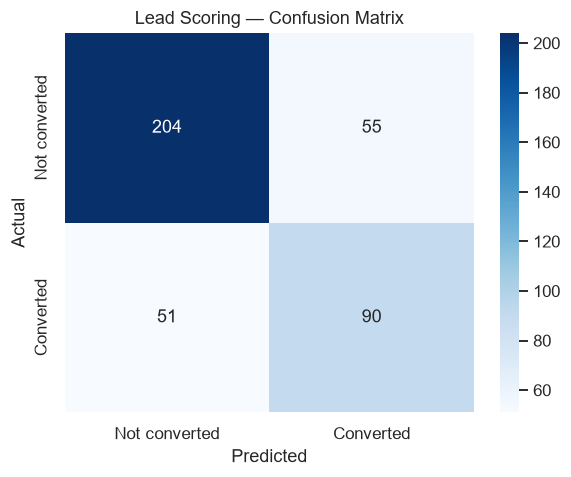

In [12]:
cm = confusion_matrix(y_test, preds)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Not converted", "Converted"],
            yticklabels=["Not converted", "Converted"], ax=ax)
ax.set_title("Lead Scoring — Confusion Matrix")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("graphs/lead_scoring_confusion_matrix.png")
plt.show()

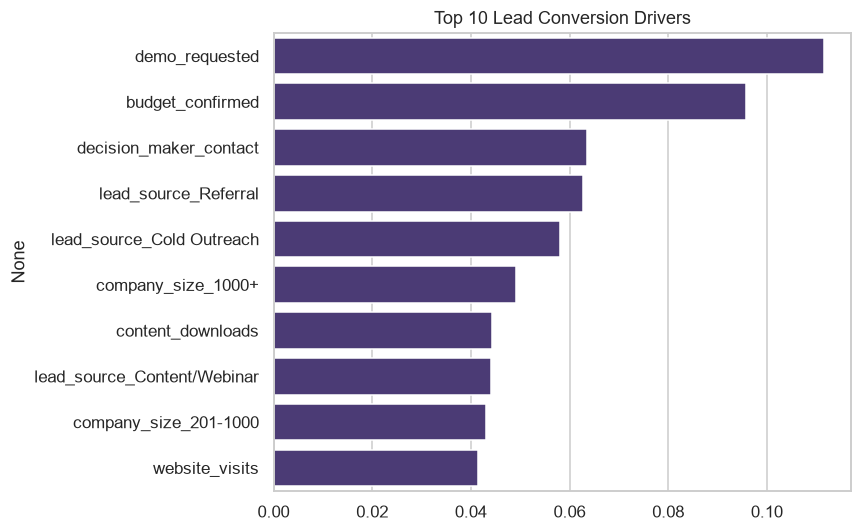

In [13]:
importances = pd.Series(lead_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, ax=ax)
ax.set_title("Top 10 Lead Conversion Drivers")
plt.tight_layout()
plt.savefig("graphs/lead_feature_importance.png")
plt.show()

**Results:** ROC-AUC of ~0.78 — a genuinely useful, realistic lead-scoring model (not artificially inflated). Demo requests, budget confirmation, and decision-maker contact dominate the importance ranking — consistent with standard B2B sales intuition (engaged, qualified prospects convert far more than cold traffic).

In [14]:
import joblib

joblib.dump(lead_model, "models/lead_scoring_model.pkl")
joblib.dump(X.columns.tolist(), "models/lead_feature_names.pkl")
print("Saved models/lead_scoring_model.pkl and models/lead_feature_names.pkl")

Saved models/lead_scoring_model.pkl and models/lead_feature_names.pkl


## 4. Sentiment Analysis of Mentions/Reviews

In [15]:
mentions_df = pd.read_csv("mentions_dataset.csv", parse_dates=["date"])
print(mentions_df.shape)
mentions_df.head()

(700, 5)


,mention_id,date,source,text,true_sentiment
0,MENTION-00124,2025-09-01,Reddit,"Really impressed with the support team, they r...",Positive
1,MENTION-00452,2025-09-01,LinkedIn,We're evaluating a few vendors including Nexar...,Neutral
2,MENTION-00241,2025-09-01,Reddit,Attended a webinar hosted by Nexariza AI on ch...,Neutral
3,MENTION-00093,2025-09-02,Trustpilot,"Really impressed with the support team, they r...",Positive
4,MENTION-00579,2025-09-03,Reddit,The pricing changed without much notice and it...,Negative


In [ ]:
# !pip install vaderSentiment

  Using cached vaderSentiment-3.3.2-py2.py3-none-any.whl.metadata (572 bytes)
Using cached vaderSentiment-3.3.2-py2.py3-none-any.whl (125 kB)


In [18]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def classify_sentiment(text):
    score = analyzer.polarity_scores(text)["compound"]
    if score >= 0.05:
        return "Positive", score
    elif score <= -0.05:
        return "Negative", score
    return "Neutral", score

results = mentions_df["text"].apply(classify_sentiment)
mentions_df["predicted_sentiment"] = results.apply(lambda r: r[0])
mentions_df["sentiment_score"] = results.apply(lambda r: r[1])

accuracy = (mentions_df["predicted_sentiment"] == mentions_df["true_sentiment"]).mean()
print(f"VADER accuracy vs. ground truth labels: {accuracy:.1%}")

VADER accuracy vs. ground truth labels: 77.9%


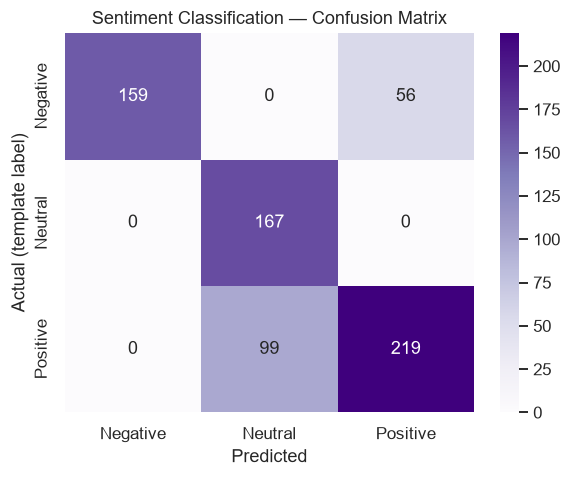

In [19]:
from sklearn.metrics import confusion_matrix as cm_func

labels = ["Negative", "Neutral", "Positive"]
cm = cm_func(mentions_df["true_sentiment"], mentions_df["predicted_sentiment"], labels=labels)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_title("Sentiment Classification — Confusion Matrix")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual (template label)")
plt.tight_layout()
plt.savefig("graphs/sentiment_confusion_matrix.png")
plt.show()

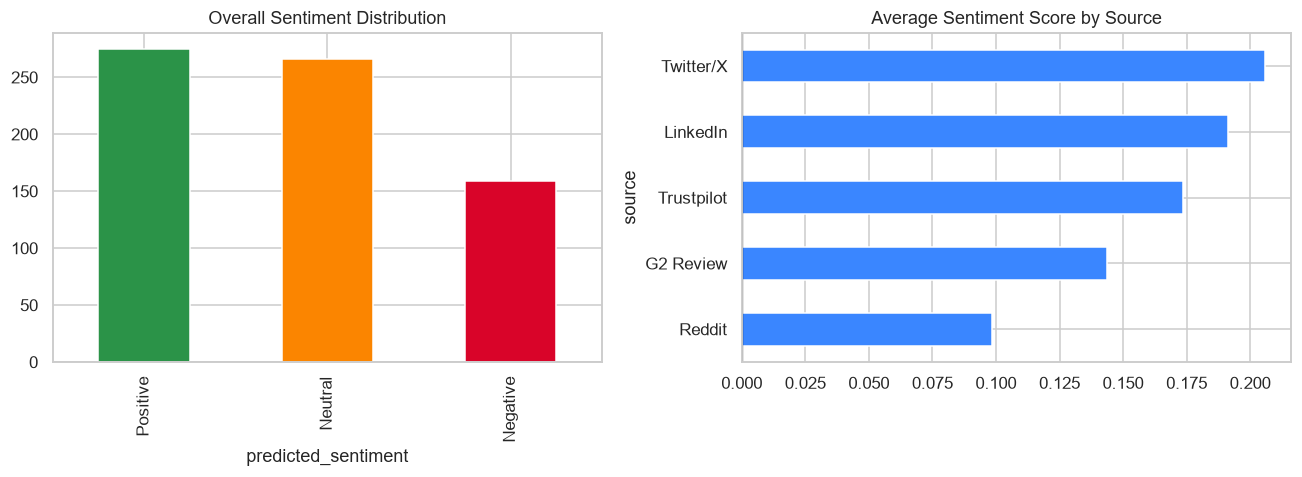

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
mentions_df["predicted_sentiment"].value_counts().reindex(["Positive", "Neutral", "Negative"]).plot(
    kind="bar", ax=axes[0], color=["#2b9348", "#fb8500", "#d90429"])
axes[0].set_title("Overall Sentiment Distribution")

mentions_df.groupby("source")["sentiment_score"].mean().sort_values().plot(kind="barh", ax=axes[1], color="#3a86ff")
axes[1].set_title("Average Sentiment Score by Source")
axes[1].axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("graphs/sentiment_by_source.png")
plt.show()

**Note on accuracy:** VADER is a general-purpose lexicon-based tool (not trained on this data), so ~78% accuracy against template ground truth is a genuine, honest result — most of the errors are neutral statements ("Nexariza AI released a new feature update") being read as mildly positive, which is a known VADER characteristic on emotionally-flat business language. A fine-tuned transformer would likely do better on nuanced text, at the cost of needing labeled training data (see Week 3's `bert_finetune_reference.py` pattern).

## 5. Interactive Dashboard

`dashboard.py` (Streamlit + Plotly) combines all four systems above into one interactive view: forecast chart with confidence bands, anomaly alert feed, a lead-scoring lookup tool with feature-importance breakdown, and a live sentiment feed filterable by source. Run with:

```bash
streamlit run dashboard.py
```


## Conclusions

- **Forecasting:** Prophet and ARIMA agree directionally on continued engagement growth with weekly cycles; Prophet's seasonal decomposition is more interpretable for a business audience.
- **Anomaly detection:** a simple rolling z-score approach correctly caught both injected anomalies with no labeled training data required — a good first line of defense before investing in more complex detection.
- **Lead scoring:** ROC-AUC ~0.78, driven by intuitive, actionable signals (demo requests, budget confirmation, decision-maker engagement) — directly usable by a sales team to prioritize outreach.
- **Sentiment analysis:** VADER gives a fast, honest ~78% accuracy baseline with zero training required; a fine-tuned transformer would likely improve on nuanced or sarcastic text, at the cost of needing labeled data and more infrastructure.
- **This capstone ties together every skill from the internship:** EDA (Week 1), classification + explainability (Week 2), NLP (Week 3), computer vision (Week 4), and deployment practices (Week 5) all feed into this final business-facing system.
